In [1]:
!pip install mediapipe opencv-python


In [2]:
import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


In [3]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles


In [4]:
def get_finger_states(hand_landmarks, image_shape):
    """
    Returns which fingers are up: [thumb, index, middle, ring, pinky]
    Using basic comparison of y-coordinates of finger tips and middle joints.
    """
    h, w, _ = image_shape

    # Finger tip indices in MediaPipe
    tip_ids = [4, 8, 12, 16, 20]

    # Convert normalized landmarks to pixel coordinates
    landmarks = []
    for lm in hand_landmarks.landmark:
        landmarks.append((int(lm.x * w), int(lm.y * h)))

    fingers = []

    # Thumb: compare x instead of y (different direction for right/left, we keep it simple)
    if landmarks[tip_ids[0]][0] < landmarks[tip_ids[0] - 1][0]:
        fingers.append(1)  # thumb up/extended
    else:
        fingers.append(0)

    # Other 4 fingers: if tip is above (less y) than the PIP joint, it is "up"
    for i in range(1, 5):
        if landmarks[tip_ids[i]][1] < landmarks[tip_ids[i] - 2][1]:
            fingers.append(1)
        else:
            fingers.append(0)

    return fingers


def classify_gesture(fingers):
    """
    Classify gesture based on finger state.
    fingers = [thumb, index, middle, ring, pinky]
    """
    total_fingers = sum(fingers)

    # All fingers folded
    if total_fingers == 0:
        return "Fist ✊"

    # All fingers extended
    if total_fingers == 5:
        return "Open Palm ✋"

    # Only thumb up
    if fingers[0] == 1 and fingers[1:] == [0, 0, 0, 0]:
        return "Thumbs Up 👍"

    # Only thumb down (we approximate using 'thumb not up but others folded')
    if fingers[0] == 0 and fingers[1:] == [0, 0, 0, 0]:
        return "Thumbs Down 👎 (approx)"

    # Index finger only
    if fingers == [0, 1, 0, 0, 0]:
        return "Pointing ☝️"

    return f"Fingers up: {total_fingers}"


In [10]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import html
import base64

# JS function to capture image from webcam
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const video = document.createElement('video');
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          // Wait for user
          await new Promise((resolve) => {
            const button = document.createElement('button');
            button.textContent = 'Capture';
            div.appendChild(button);
            button.onclick = () => resolve();
          });

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

print("Click the 'Capture' button when webcam opens...")
photo_filename = take_photo()
print("Saved to", photo_filename)


Click the 'Capture' button when webcam opens...


<IPython.core.display.Javascript object>

Saved to photo.jpg


Gesture: Fingers up: 2


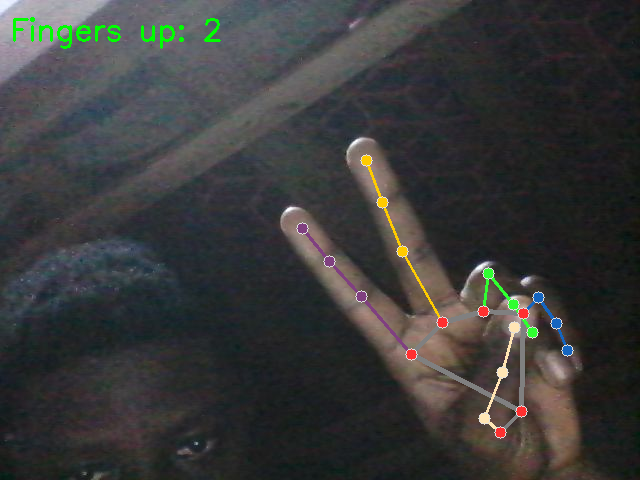

In [11]:
image = cv2.imread(photo_filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5
) as hands:

    results = hands.process(image_rgb)

    # ✅ use multi_hand_landmarks here
    if not results.multi_hand_landmarks:
        print("No hands detected.")
    else:
        for hand_landmarks in results.multi_hand_landmarks:
            # Draw landmarks
            mp_drawing.draw_landmarks(
                image,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style()
            )

            fingers = get_finger_states(hand_landmarks, image.shape)
            gesture = classify_gesture(fingers)
            print("Gesture:", gesture)

            # Put text on image
            cv2.putText(image, gesture, (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [13]:
video_path = 'hand_gestures.mp4'  # change if your file name differs

cap = cv2.VideoCapture(video_path)

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as hands:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (640, 480))
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        results = hands.process(frame_rgb)

        gesture_text = ""

        # ✅ use multi_hand_landmarks here
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    frame,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing_styles.get_default_hand_landmarks_style(),
                    mp_drawing_styles.get_default_hand_connections_style()
                )

                fingers = get_finger_states(hand_landmarks, frame.shape)
                gesture_text = classify_gesture(fingers)

        if gesture_text:
            cv2.putText(frame, gesture_text, (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2_imshow(frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


In [14]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

video_path = "hand_video.mp4"   # <<--- change this to your uploaded file name

cap = cv2.VideoCapture(video_path)

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as hands:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (640, 480))
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        results = hands.process(frame_rgb)

        gesture_text = ""

        # Detect hand landmarks
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:

                # Draw landmarks
                mp_drawing.draw_landmarks(
                    frame,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing_styles.get_default_hand_landmarks_style(),
                    mp_drawing_styles.get_default_hand_connections_style()
                )

                # Finger detection
                fingers = get_finger_states(hand_landmarks, frame.shape)
                gesture_text = classify_gesture(fingers)

        # Display gesture text
        if gesture_text:
            cv2.putText(frame, gesture_text, (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2_imshow(frame)

cap.release()
cv2.destroyAllWindows()
